In [1]:
import pandas as pd
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from datetime import datetime
import re

pd.set_option('display.max_columns', None)   # 显示所有列
pd.set_option('display.max_rows', 100)       # 最多显示100行（可自行调整）
pd.set_option('display.width', 200)          # 控制输出宽度，防止换行
pd.set_option('display.max_colwidth', 50)    # 控制每列的最大字符宽度（默认50，可改为None）

In [81]:
rent_train = pd.read_csv("C:/Users\lenovo\Desktop\Data/ruc_Class25Q2_train_price.csv")  # or train_price
rent_test = pd.read_csv("C:/Users\lenovo\Desktop\Data/ruc_Class25Q2_test_price.csv")    # or test_price

In [136]:
# 方法2：在Jupyter Notebook中
import sys
sys.path.append("C:/Users\lenovo\Desktop/")
import DataClean_price_v2
import importlib
importlib.reload(DataClean_price_v2)
import DataClean_price_v2
from DataClean_price_v2 import *

In [119]:
TRAIN_PATH = "C:/Users\lenovo\Desktop\Data/ruc_Class25Q2_train_price.csv" # 假设文件在同目录下
TEST_PATH = "C:/Users\lenovo\Desktop\Data/ruc_Class25Q2_test_price.csv"   # 假设文件在同目录下
OUTPUT_TRAIN_PATH = "Price_train_cleaned_refactored.csv"
OUTPUT_TEST_PATH = "Price_test_cleaned_refactored.csv"

In [122]:
train = pd.read_csv("C:/Users\lenovo\Desktop\Data/ruc_Class25Q2_train_price.csv")

In [133]:
train['房屋用途'].value_counts()

房屋用途
普通住宅      96099
商住两用       3066
别墅         2032
商业办公类      1527
车库          580
公寓          311
商务公寓        144
酒店式公寓        55
公寓/公寓        14
新式里弄         10
公寓/住宅         5
商务型公寓         5
底商            5
写字楼           4
老公寓           3
商业            3
四合院           3
公寓（住宅）        2
花园洋房          1
住宅式公寓         1
Name: count, dtype: int64

In [137]:
train_cleaned, test_cleaned = clean_price_data(
    TRAIN_PATH,
    TEST_PATH,
    OUTPUT_TRAIN_PATH,
    OUTPUT_TEST_PATH,
    target_col='Price/m2' # 明确目标列为 Price
)

开始加载房价数据...
训练集形状: (103871, 55)
测试集形状: (34017, 55)

步骤1: 处理交易时间

【第1.5步】统一缺失值表示...
  建筑结构: 替换了 4808 个伪缺失值
总共替换了 4808 个伪缺失值为NaN

步骤2: 解析特殊文本列（楼层、梯户比、户型）

步骤3: 通用数值清洗（提取带单位的数值）

步骤4: 删除无用列
已删除列: ['开发商', '物业公司', '物业办公电话', '交易时间', '环线位置', '板块', '所在楼层', '梯户比例', '房屋户型', '抵押信息', '上次交易']

步骤5: 填充缺失值
  开始层级填充...
    ✓ 套内面积基于建筑面积填充: 训练集67887条, 测试集24102条
    正在层级填充 18 个数值列...
      - 物 业 费: 31158 -> 0 (填充31158条)
      - 停车费用: 35967 -> 0 (填充35967条)
      - 停车位: 34568 -> 0 (填充34568条)
      - 容 积 率: 33154 -> 0 (填充33154条)
      - 绿 化 率: 32883 -> 0 (填充32883条)
      - 楼栋总数: 7131 -> 0 (填充7131条)
      - 房屋总数: 7131 -> 0 (填充7131条)
      - 建筑年代: 35101 -> 0 (填充35101条)
      - 燃气费: 32701 -> 0 (填充32701条)
      - 梯户比: 2619 -> 0 (填充2619条)
      - 卧室数: 1299 -> 0 (填充1299条)
      - 客厅数: 1299 -> 0 (填充1299条)
      - 厨房数: 1299 -> 0 (填充1299条)
      - 卫生间数: 580 -> 0 (填充580条)
    ✓ '房屋用途'列存在，缺失值数: 103871
    '房屋用途'前10个值:
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: 房屋用途, dtype: fl

In [139]:
train_cleaned = train_cleaned.drop(columns = ['房屋用途_nan','房屋优势_Unknown'])
test_cleaned = test_cleaned.drop(columns = ['房屋用途_nan','房屋优势_Unknown'])

In [95]:
train_cleaned['房龄'] = train_cleaned['建筑年代'].apply(lambda x: 2025 - x if x != '未知' else np.nan)
test_cleaned['房龄'] = test_cleaned['建筑年代'].apply(lambda x: 2025 - x if x != '未知' else np.nan)
train_cleaned = train_cleaned.drop(columns = ['建筑年代', '距上次交易年数'])
test_cleaned = test_cleaned.drop(columns = ['建筑年代', '距上次交易年数'])
train_cleaned.head()

,城市_0,城市_1,城市_2,城市_3,城市_4,城市_5,城市_6,城市_7,城市_8,城市_9,城市_10,城市_11,Price,建筑面积,套内面积,lon,lat,年份,房屋总数,楼栋总数,绿 化 率,容 积 率,物 业 费,燃气费,停车位,停车费用,coord_x,coord_y,交易距今年数,当前楼层,总楼层,梯户比,卧室数,客厅数,厨房数,卫生间数,环线_三至四环,环线_中环至外环,环线_二环内,环线_二至三环,环线_五至六环,环线_六环外,环线_内环内,环线_内环至中环,环线_内环至外环,环线_四至五环,环线_外环外,建筑结构_未知,建筑结构_未知结构,建筑结构_框架结构,建筑结构_混合结构,建筑结构_砖木结构,建筑结构_砖混结构,建筑结构_钢混结构,建筑结构_钢结构,装修情况_其他,装修情况_毛坯,装修情况_简装,装修情况_精装,配备电梯_无,配备电梯_有,别墅类型_双拼,别墅类型_叠拼,别墅类型_独栋,别墅类型_联排,交易权属_一类经济适用房,交易权属_二类经济适用房,交易权属_动迁安置房,交易权属_售后公房,交易权属_商品房,交易权属_回迁房,交易权属_央产房,交易权属_定向安置房,交易权属_已购公房,交易权属_房改房,交易权属_拆迁还建房,交易权属_私产,交易权属_经济适用房,交易权属_限价商品房,交易权属_集资房,房屋用途_未知,房屋年限_未满两年,房屋年限_满两年,房屋年限_满五年,产权所属_共有,产权所属_非共有,房屋朝向_东,房屋朝向_东北,房屋朝向_东南,房屋朝向_北,房屋朝向_南,房屋朝向_西,房屋朝向_西北,房屋朝向_西南,物业类别_人防车位,物业类别_住宅,物业类别_住宅式公寓,物业类别_公寓,物业类别_公寓（住宅）,物业类别_写字楼,物业类别_别墅,物业类别_单身公寓（住宅）,物业类别_商业,物业类别_商业办公类,物业类别_商住两用,物业类别_商务公寓,物业类别_商务型公寓,物业类别_四合院,物业类别_地下仓储,物业类别_工业厂房,物业类别_平房,物业类别_库房,物业类别_底商,物业类别_新式里弄,物业类别_旧式里弄,物业类别_普通住宅,物业类别_老公寓,物业类别_花园洋房,物业类别_车库,物业类别_酒店式公寓,建筑结构_comm_塔板结合,建筑结构_comm_塔楼,建筑结构_comm_平房,建筑结构_comm_板楼,产权描述_一类经济适用房,产权描述_乡产,产权描述_二类经济适用房,产权描述_使用权,产权描述_公租房,产权描述_共有产权房,产权描述_军产,产权描述_动迁安置房,产权描述_售后公房,产权描述_商品房,产权描述_回迁房,产权描述_央产房,产权描述_宅基房,产权描述_安居型商品房,产权描述_定向安置房,产权描述_已购公房,产权描述_廉租房,产权描述_房改房,产权描述_拆迁还建房,产权描述_校产,产权描述_私产,产权描述_经济适用房,产权描述_自住型商品房,产权描述_限价商品房,产权描述_集资房,供水_商水,供水_民水,供暖_无供暖,供暖_自采暖,供暖_集中供暖,供电_商电,供电_民电,房屋优势_地铁,房屋优势_房本满两年,房屋优势_房本满五年,房屋优势_装修,区域_均价编码,板块_均价编码,房龄
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.194049e+06,52.30,44.455,117.424278,40.975752,2018.0,1317.0,19.0,0.300,3.00,1.475,2.61,300.0,0.0,117.424278,40.975752,4,2.5,5.0,0.333333,2.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,1,1,133505.606329,146909.550178,47.5
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.354153e+06,127.44,123.700,117.389228,41.091295,2017.0,2317.0,40.0,0.300,1.73,0.650,2.61,1550.0,150.0,117.389228,41.091295,5,6.0,6.0,0.500000,3.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,1,0,1,1,0,0,1,1,41437.214860,44302.032009,20.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.321992e+06,118.02,101.950,117.200934,40.747919,2018.0,1554.0,20.0,0.300,1.70,2.480,2.61,324.0,150.0,117.200934,40.747919,5,1.2,6.0,0.200000,3.0,2.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,1,1,1,1,1,0,1,1,28278.113469,28556.739152,13.5
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.895656e+06,293.23,293.230,117.767308,41.228803,2020.0,66.0,27.0,0.401,1.00,4.535,2.62,500.0,0.0,117.767308,41.228803,2,1.0,2.0,0.500000,6.0,3.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,37592.282261,28085.573482,15.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.902960e+06,39.85,29.940,117.334530,40.952530,2017.0,1685.0,19.0,0.600,1.58,5.150,2.62,1800.0,1200.0,117.334530,40.952530,6,5.0,10.0,0.200000,3.0,2.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.

In [140]:
train_cleaned.shape

(103871, 161)

In [141]:
test_cleaned.shape

(34017, 161)

### 聚类小区

Fitting HDBSCAN on training coords...
clusters found: 3
example cluster sizes (top 10): [5000, 5000, 5000]
Train cluster id value counts (top 10):
cluster_id
2    5000
1    5000
0    5000
Name: count, dtype: int64
Test cluster id value counts (top 10):
cluster_id
-1    3000
Name: count, dtype: int64
p90s median: 15308.57875555823 p90s 75pct: 15708.058270807407


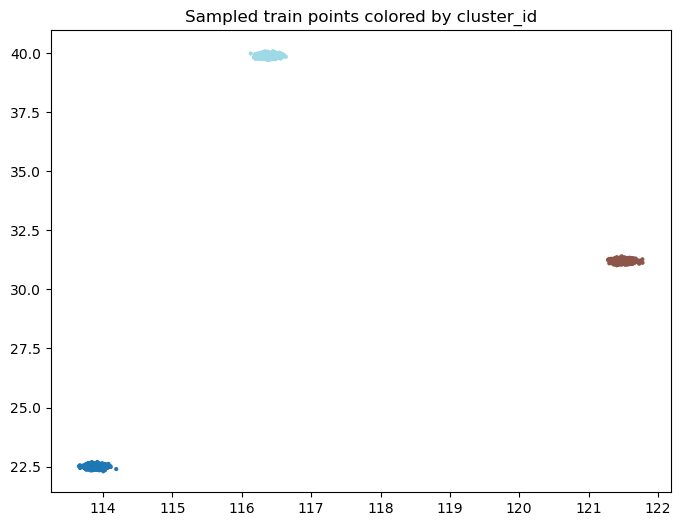

encoder saved to hdbscan_geo_encoder.joblib


In [142]:
"""
改进版 HDBSCANGeoEncoder（替换 / 更新你当前的类）

主要修改与增强：
- fit 时强制开启 prediction_data=True（以便 hdbscan.approximate_predict 可用）
- transform 中对 approximate_predict 使用 try/except，并在不可用或返回低置信度时稳健回退到 BallTree 的 kNN 加权投票或 radius 投票
- 提供 compute_cluster_radii 帮助选择 eps_m（基于簇内距离的 p50/p75/p90 分位数）
- 增强兼容性与健壮性（检测 prediction_data_、处理 hdbscan 版本差异）
- 提供 save/load（joblib）以及 explore_min_cluster_size 辅助函数

依赖: pip install hdbscan scikit-learn numpy pandas joblib
"""
import numpy as np
import pandas as pd
from sklearn.neighbors import BallTree
import hdbscan
from collections import Counter
import joblib
import math
import warnings

EARTH_RADIUS = 6371000.0  # m

def deg2rad_degorder(coords_deg):
    """
    输入: Nx2 array [lon, lat] degrees
    输出: Nx2 array [lat_rad, lon_rad]
    """
    arr = np.asarray(coords_deg, dtype=float)
    if arr.ndim != 2 or arr.shape[1] != 2:
        raise ValueError("coords must be shape (n,2) [lon, lat]")
    rad = np.radians(arr)
    return np.vstack([rad[:,1], rad[:,0]]).T  # [lat_rad, lon_rad]

def haversine_angle_rad(a, b):
    """
    计算球面中心角（弧度）
    a: [lat_rad, lon_rad] 或形状 (...,2)
    b: (...,2) 或单点
    返回: array radians
    """
    a = np.asarray(a)
    b = np.asarray(b)
    # support broadcasting: if b is (n,2) and a is (2,) or (m,2)
    lat1 = a[..., 0]
    lon1 = a[..., 1]
    lat2 = b[..., 0]
    lon2 = b[..., 1]
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    sa = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    sa = np.minimum(1.0, np.maximum(0.0, sa))
    return 2.0 * np.arcsin(np.sqrt(sa))

def rad_to_m(rad):
    return rad * EARTH_RADIUS

class HDBSCANGeoEncoder:
    """
    HDBSCANGeoEncoder: 在训练集上 fit 一次 HDBSCAN，然后对新点做可复用的编码/分配。

    参数:
      min_cluster_size, min_samples, eps_m (meters fallback radius),
      assign_strategy: 'approximate' | 'nearest' | 'keep_noise'
      hdbscan_params: dict 额外传给 hdbscan.HDBSCAN
      hdbscan_prob_threshold: 若 approximate_predict 返回 strength < 阈值则视为低置信度，触发 fallback
      knn_k: fallback 时使用的 kNN 个数（加权投票）
    """
    def __init__(self, min_cluster_size=50, min_samples=None, eps_m=500,
                 assign_strategy='nearest', hdbscan_params=None, hdbscan_prob_threshold=0.05,
                 knn_k=3):
        assert assign_strategy in ('approximate', 'nearest', 'keep_noise')
        self.min_cluster_size = min_cluster_size
        self.min_samples = min_samples
        self.eps_m = eps_m
        self.assign_strategy = assign_strategy
        self.hdbscan_params = hdbscan_params or {}
        self.hdbscan_prob_threshold = hdbscan_prob_threshold
        self.knn_k = knn_k

        self.clusterer_ = None
        self.train_rad_ = None  # Nx2 [lat_rad, lon_rad]
        self.train_deg_ = None  # Nx2 [lon, lat]
        self.train_labels_ = None
        self.balltree_ = None
        self.cluster_centers_rad_ = {}  # label -> [lat_rad, lon_rad]
        self.cluster_sizes_ = {}
        self.cluster_persistence_ = {}
        self.fitted = False

    def fit(self, coords_deg):
        """
        在训练集上 fit HDBSCAN.
        coords_deg: array-like Nx2 [lon, lat] degrees OR DataFrame with ['lon','lat']
        注意: 强制 prediction_data=True 以支持 approximate_predict
        """
        if isinstance(coords_deg, pd.DataFrame):
            coords_deg = coords_deg[['lon','lat']].values
        coords_deg = np.asarray(coords_deg, dtype=float)
        self.train_deg_ = coords_deg.copy()
        self.train_rad_ = deg2rad_degorder(coords_deg)  # [lat_rad, lon_rad]

        params = dict(min_cluster_size=self.min_cluster_size,
                      metric='haversine',
                      prediction_data=True,   # 关键：生成 prediction_data_ 以便 approximate_predict 使用
                      core_dist_n_jobs=4)
        if self.min_samples is not None:
            params['min_samples'] = self.min_samples
        params.update(self.hdbscan_params)

        # fit
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", message=".*force_all_finite.*", category=FutureWarning)
            self.clusterer_ = hdbscan.HDBSCAN(**params)
            self.clusterer_.fit(self.train_rad_)

        labels = self.clusterer_.labels_
        self.train_labels_ = labels
        # BallTree for fallback assignment; metric='haversine' expects radian input [lat, lon]
        self.balltree_ = BallTree(self.train_rad_, metric='haversine')

        # compute centers and sizes
        uniq = set(labels)
        for lab in uniq:
            if lab == -1:
                continue
            mask = (labels == lab)
            pts = self.train_rad_[mask]
            if pts.shape[0] == 0:
                continue
            lat_mean = float(np.mean(pts[:,0]))
            lon_mean = float(np.mean(pts[:,1]))
            self.cluster_centers_rad_[lab] = np.array([lat_mean, lon_mean])
            self.cluster_sizes_[lab] = int(mask.sum())

        # persistence if available
        try:
            pers = getattr(self.clusterer_, 'cluster_persistence_', None)
            if pers is not None:
                # try mapping cluster indices to labels best-effort
                if isinstance(pers, dict):
                    self.cluster_persistence_ = pers.copy()
                else:
                    labs_sorted = sorted([l for l in set(labels) if l != -1])
                    for i, lab in enumerate(labs_sorted):
                        if i < len(pers):
                            self.cluster_persistence_[lab] = float(pers[i])
        except Exception:
            # 不影响主流程
            pass

        self.fitted = True
        return self

    def _knn_weighted_vote(self, coords_rad, k=3, max_dist_m=None):
        """
        对一组点使用 kNN 加权投票分配标签（忽略训练中 label==-1）
        coords_rad: Nx2 [lat_rad, lon_rad]
        返回: labels array
        """
        n = coords_rad.shape[0]
        labels_out = np.full(n, -1, dtype=int)
        dists_rad, idxs = self.balltree_.query(coords_rad, k=k)
        dists_m = dists_rad * EARTH_RADIUS  # shape (n,k)
        for i in range(n):
            labs = self.train_labels_[idxs[i]]  # k labels
            # filter out -1 neighbors
            mask = (labs != -1)
            if mask.sum() == 0:
                labels_out[i] = -1
                continue
            labs = labs[mask]
            dms = dists_m[i][mask]
            if (max_dist_m is not None) and (dms.min() > max_dist_m):
                labels_out[i] = -1
                continue
            # weights: inverse distance
            w = 1.0 / (dms + 1e-6)
            vote_scores = {}
            for lab, wi in zip(labs, w):
                vote_scores[int(lab)] = vote_scores.get(int(lab), 0.0) + wi
            chosen = max(vote_scores.items(), key=lambda x: x[1])[0]
            labels_out[i] = int(chosen)
        return labels_out

    def _radius_vote(self, coords_rad, radius_m):
        """
        半径内多数投票（radius-based). radius_m in meters
        """
        radius_rad = radius_m / EARTH_RADIUS
        idxs_list = self.balltree_.query_radius(coords_rad, r=radius_rad, return_distance=False)
        n = coords_rad.shape[0]
        labels_out = np.full(n, -1, dtype=int)
        for i, neigh in enumerate(idxs_list):
            if len(neigh) == 0:
                labels_out[i] = -1
            else:
                labs = self.train_labels_[neigh]
                c = Counter(labs[labs != -1])
                if len(c) == 0:
                    labels_out[i] = -1
                else:
                    labels_out[i] = c.most_common(1)[0][0]
        return labels_out

    def transform(self, coords_deg, return_more=False):
        """
        Assign cluster ids to coords_deg (lon, lat deg)
        return_more: if True, returns (labels, cluster_size, dist_to_center_m, membership_strength)
        """
        if not self.fitted:
            raise RuntimeError("Call fit() before transform()")
        if isinstance(coords_deg, pd.DataFrame):
            coords_deg = coords_deg[['lon','lat']].values
        coords_deg = np.asarray(coords_deg, dtype=float)
        coords_rad = deg2rad_degorder(coords_deg)  # [lat_rad, lon_rad]
        n = coords_rad.shape[0]
        labels_out = np.full(n, -1, dtype=int)
        cluster_size_arr = np.zeros(n, dtype=int)
        dist_to_center_m = np.full(n, np.nan, dtype=float)
        strength_arr = np.full(n, np.nan, dtype=float)

        # 尝试 approximate_predict（如果可用且 prediction data 存在）
        use_approx = hasattr(hdbscan, 'approximate_predict') and getattr(self.clusterer_, 'prediction_data_', None) is not None
        if use_approx:
            try:
                labs, strengths = hdbscan.approximate_predict(self.clusterer_, coords_rad)
                labels_out = np.array(labs, dtype=int)
                strength_arr = np.array(strengths, dtype=float)
            except Exception:
                use_approx = False

        # 处理 approximate_predict 的低置信度或 label == -1 情况，根据策略回退
        if use_approx:
            low_mask = (strength_arr < self.hdbscan_prob_threshold)
            # 若 assign_strategy 是 nearest，则对低置信度/噪声尝试 knn 加权投票或 radius 投票
            if self.assign_strategy == 'nearest':
                # 先对 low confidence / -1 使用 knn weighted vote (k=self.knn_k) 并限制 max_dist = eps_m
                idxs_low = np.where((labels_out == -1) | low_mask)[0]
                if idxs_low.size > 0:
                    coords_low = coords_rad[idxs_low]
                    assigned = self._knn_weighted_vote(coords_low, k=self.knn_k, max_dist_m=self.eps_m)
                    for i, lab in zip(idxs_low, assigned):
                        labels_out[i] = int(lab)
                        if lab != -1:
                            strength_arr[i] = 0.0  # 标注为低置信度分配
            elif self.assign_strategy == 'keep_noise':
                # 保持 approximate_predict 的结果（包括 -1）
                pass
            elif self.assign_strategy == 'approximate':
                # 接受 approximate_predict 即使 strength 低
                pass
        else:
            # approximate_predict 不可用或失败 -> 直接使用 knn weighted vote 或 radius vote
            if self.assign_strategy == 'nearest':
                labels_out = self._knn_weighted_vote(coords_rad, k=self.knn_k, max_dist_m=self.eps_m)
            elif self.assign_strategy == 'keep_noise':
                labels_out = np.full(n, -1, dtype=int)
            elif self.assign_strategy == 'approximate':
                # 没有 approximate_predict 就相当于 keep_noise
                labels_out = np.full(n, -1, dtype=int)

        # 计算 cluster_size 和 dist_to_center
        for i, lab in enumerate(labels_out):
            if lab == -1:
                continue
            cluster_size_arr[i] = self.cluster_sizes_.get(lab, 0)
            center = self.cluster_centers_rad_.get(lab, None)
            if center is not None:
                ang = haversine_angle_rad(center, coords_rad[i])
                dist_to_center_m[i] = rad_to_m(ang)

        if return_more:
            return labels_out, cluster_size_arr, dist_to_center_m, strength_arr
        return labels_out

    def fit_transform(self, coords_deg, return_more=False):
        self.fit(coords_deg)
        return self.transform(coords_deg, return_more=return_more)

    def save(self, path):
        joblib.dump(self, path)

    @staticmethod
    def load(path):
        return joblib.load(path)


# ----------------------------
# Utility: compute cluster radii & explore helper
# ----------------------------
def compute_cluster_radii(enc):
    """
    输入 enc (fit 完的 HDBSCANGeoEncoder)，输出每个簇到簇心距离统计（米）
    返回: dict label -> {'n','p50','p75','p90','p95','max'}
    """
    if not enc.fitted:
        raise RuntimeError("encoder not fitted")
    stats = {}
    labels = enc.train_labels_
    centers = enc.cluster_centers_rad_
    coords = enc.train_rad_
    unique_labels = [l for l in np.unique(labels) if l != -1]
    for lab in unique_labels:
        mask = (labels == lab)
        pts = coords[mask]
        if pts.shape[0] == 0:
            continue
        center = centers.get(lab, None)
        if center is None:
            continue
        angs = haversine_angle_rad(center, pts)  # radians
        dists_m = angs * EARTH_RADIUS
        stats[lab] = {
            'n': int(mask.sum()),
            'p50': float(np.percentile(dists_m, 50)),
            'p75': float(np.percentile(dists_m, 75)),
            'p90': float(np.percentile(dists_m, 90)),
            'p95': float(np.percentile(dists_m, 95)),
            'max': float(np.max(dists_m))
        }
    return stats

def explore_min_cluster_size(coords_deg, min_sizes=(10,20,30,50,80,120), min_samples=None):
    """
    Sweep 不同 min_cluster_size 的影响（返回 DataFrame）
    """
    res = []
    for mcs in min_sizes:
        enc = HDBSCANGeoEncoder(min_cluster_size=mcs, min_samples=min_samples or max(1, mcs//3))
        enc.fit(coords_deg)
        labs = enc.train_labels_
        ncl = len(set(labs)) - (1 if -1 in labs else 0)
        noise_frac = float(np.mean(labs == -1))
        sizes = list(enc.cluster_sizes_.values())
        median_size = float(np.median(sizes)) if len(sizes)>0 else 0.0
        res.append({'min_cluster_size': mcs, 'n_clusters': ncl, 'noise_frac': noise_frac, 'median_cluster_size': median_size})
    return pd.DataFrame(res)


# ----------------------------
# Example usage（脚本直接运行时）
# ----------------------------
if __name__ == "__main__":
    import matplotlib.pyplot as plt

    # demo 数据（替换为你的 df_train/df_test）
    n = 20000
    rng = np.random.RandomState(0)
    centers = [(116.4,39.9),(121.5,31.2),(113.9,22.5),(108.9,34.3)]
    pts = []
    for cx, cy in centers:
        pts.append(np.vstack([rng.normal(cx, 0.08, n//len(centers)), rng.normal(cy, 0.06, n//len(centers))]).T)
    coords = np.vstack(pts)
    df_train = pd.DataFrame(coords[:15000], columns=['lon','lat'])
    df_test = pd.DataFrame(coords[15000:18000], columns=['lon','lat'])

    enc = HDBSCANGeoEncoder(min_cluster_size=50, min_samples=10, eps_m=500, assign_strategy='nearest', knn_k=3)
    print("Fitting HDBSCAN on training coords...")
    enc.fit(df_train[['lon','lat']].values)
    print("clusters found:", len(enc.cluster_centers_rad_))
    print("example cluster sizes (top 10):", sorted(enc.cluster_sizes_.values(), reverse=True)[:10])

    labs_tr, size_tr, dist_tr, strength_tr = enc.transform(df_train[['lon','lat']].values, return_more=True)
    labs_te, size_te, dist_te, strength_te = enc.transform(df_test[['lon','lat']].values, return_more=True)

    df_train['cluster_id'] = labs_tr
    df_train['cluster_size'] = size_tr
    df_train['dist_to_center_m'] = dist_tr
    df_train['cluster_strength'] = strength_tr

    df_test['cluster_id'] = labs_te
    df_test['cluster_size'] = size_te
    df_test['dist_to_center_m'] = dist_te
    df_test['cluster_strength'] = strength_te

    print("Train cluster id value counts (top 10):")
    print(df_train['cluster_id'].value_counts().head(10))
    print("Test cluster id value counts (top 10):")
    print(df_test['cluster_id'].value_counts().head(10))

    # compute cluster radii stats and suggest eps_m
    stats = compute_cluster_radii(enc)
    p90s = np.array([v['p90'] for v in stats.values()])
    if len(p90s) > 0:
        print("p90s median:", np.median(p90s), "p90s 75pct:", np.percentile(p90s,75))
    else:
        print("No clusters to compute radii.")

    # simple sampled plot
    sample_tr = df_train.sample(min(3000, len(df_train)), random_state=0)
    plt.figure(figsize=(8,6))
    plt.scatter(sample_tr['lon'], sample_tr['lat'], c=sample_tr['cluster_id'], cmap='tab20', s=4)
    plt.title('Sampled train points colored by cluster_id')
    plt.show()

    enc.save('hdbscan_geo_encoder.joblib')
    print("encoder saved to hdbscan_geo_encoder.joblib")

In [143]:
cluster_train = train_cleaned[['lon','lat']]
cluster_test = test_cleaned[['lon','lat']]

Fitting HDBSCAN on training coords...
clusters found: 2202
example cluster sizes (top 10): [694, 651, 630, 548, 473, 371, 357, 356, 342, 332]
Train cluster id value counts (top 10):
cluster_id
-1       3865
 1416     694
 564      651
 680      630
 524      548
 1324     473
 134      371
 382      357
 133      356
 1375     342
Name: count, dtype: int64
Test cluster id value counts (top 10):
cluster_id
-1       3398
 680      241
 34       170
 333      149
 563      139
 1808     135
 93       131
 1338     126
 26       123
 1057     118
Name: count, dtype: int64


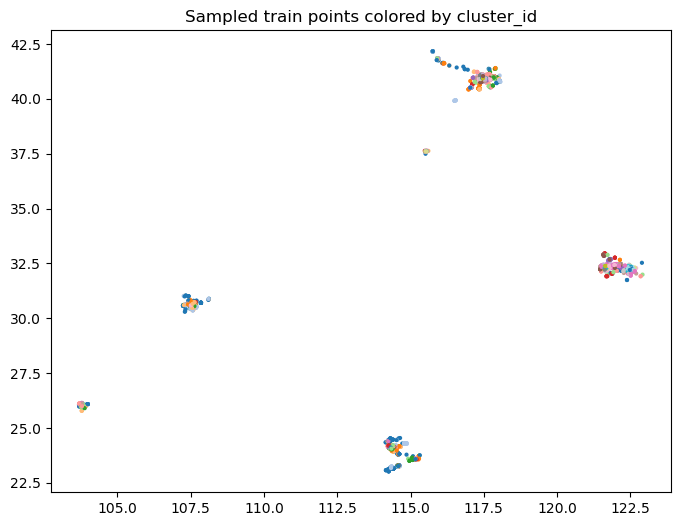

encoder saved to hdbscan_geo_encoder.joblib


In [144]:
# 假设 HDBSCANGeoEncoder 类已正确定义并导入为 enc
enc = HDBSCANGeoEncoder(min_cluster_size=5, min_samples=10, eps_m=500, assign_strategy='nearest')
print("Fitting HDBSCAN on training coords...")
enc.fit(cluster_train[['lon','lat']].values)

print("clusters found:", len(enc.cluster_centers_rad_))
print("example cluster sizes (top 10):", sorted(enc.cluster_sizes_.values(), reverse=True)[:10])

# transform train & test (注意这里 test 用 cluster_test)
labs_tr, size_tr, dist_tr, strength_tr = enc.transform(cluster_train[['lon','lat']].values, return_more=True)
labs_te, size_te, dist_te, strength_te = enc.transform(cluster_test[['lon','lat']].values, return_more=True)

cluster_train['cluster_id'] = labs_tr
cluster_train['cluster_size'] = size_tr
cluster_train['dist_to_center_m'] = dist_tr
cluster_train['cluster_strength'] = strength_tr

cluster_test['cluster_id'] = labs_te
cluster_test['cluster_size'] = size_te
cluster_test['dist_to_center_m'] = dist_te
cluster_test['cluster_strength'] = strength_te

print("Train cluster id value counts (top 10):")
print(cluster_train['cluster_id'].value_counts().head(10))
print("Test cluster id value counts (top 10):")
print(cluster_test['cluster_id'].value_counts().head(10))

# simple plot (sampled)
sample_tr = cluster_train.sample(min(3000, len(cluster_train)), random_state=0)
plt.figure(figsize=(8,6))
plt.scatter(sample_tr['lon'], sample_tr['lat'], c=sample_tr['cluster_id'], cmap='tab20', s=4)
plt.title('Sampled train points colored by cluster_id')
plt.show()

# save encoder for later use
enc.save('hdbscan_geo_encoder.joblib')
print("encoder saved to hdbscan_geo_encoder.joblib")

In [145]:
# 简单实现
import pandas as pd
train_cleaned['Price/m2'] = train_cleaned['Price'] / train_cleaned['套内面积']
cluster_train['price'] = train_cleaned['Price/m2']
global_mean = cluster_train['price'].mean()


# 训练集：每行填充自己簇的均值
cluster_train['cluster_price_mean'] = cluster_train.groupby('cluster_id')['price'].transform('mean')

# 计算训练集上的簇均值字典（用于映射 test）
cluster_means = cluster_train.groupby('cluster_id')['price'].mean().to_dict()

# 测试集：用训练集统计的均值映射，未见簇或 NaN 填充全局均值
cluster_test['cluster_price_mean'] = cluster_test['cluster_id'].map(cluster_means)

In [146]:
train_cleaned['cluster_id'] = cluster_train['cluster_id']
train_cleaned['cluster_mean_price'] = cluster_train['cluster_price_mean']
test_cleaned['cluster_id'] = cluster_test['cluster_id']
test_cleaned['cluster_mean_price'] = cluster_test['cluster_price_mean']

In [147]:
mask = train_cleaned['cluster_id'] == -1
train_cleaned.loc[mask, 'cluster_mean_price'] = train_cleaned.loc[mask, '板块_均价编码']

In [148]:
mask = test_cleaned['cluster_id'] == -1
test_cleaned.loc[mask, 'cluster_mean_price'] = test_cleaned.loc[mask, '板块_均价编码']

In [149]:
test_cleaned.head()

,城市_0,城市_1,城市_2,城市_3,城市_4,城市_5,城市_6,城市_7,城市_8,城市_9,城市_10,城市_11,ID,建筑面积,套内面积,lon,lat,年份,建筑年代,房屋总数,楼栋总数,绿 化 率,容 积 率,物 业 费,燃气费,停车位,停车费用,coord_x,coord_y,交易距今年数,距上次交易年数,当前楼层,总楼层,梯户比,卧室数,客厅数,厨房数,卫生间数,环线_三至四环,环线_中环至外环,环线_二环内,环线_二至三环,环线_五至六环,环线_六环外,环线_内环内,环线_内环至中环,环线_内环至外环,环线_四至五环,环线_外环外,建筑结构_框架结构,建筑结构_混合结构,建筑结构_砖木结构,建筑结构_砖混结构,建筑结构_钢混结构,建筑结构_钢结构,装修情况_其他,装修情况_毛坯,装修情况_简装,装修情况_精装,配备电梯_无,配备电梯_有,别墅类型_双拼,别墅类型_叠拼,别墅类型_独栋,别墅类型_联排,交易权属_一类经济适用房,交易权属_二类经济适用房,交易权属_动迁安置房,交易权属_售后公房,交易权属_商品房,交易权属_回迁房,交易权属_央产房,交易权属_定向安置房,交易权属_已购公房,交易权属_房改房,交易权属_拆迁还建房,交易权属_私产,交易权属_经济适用房,交易权属_限价商品房,交易权属_集资房,房屋年限_未满两年,房屋年限_满两年,房屋年限_满五年,产权所属_共有,产权所属_非共有,房屋朝向_东,房屋朝向_东北,房屋朝向_东南,房屋朝向_北,房屋朝向_南,房屋朝向_西,房屋朝向_西北,房屋朝向_西南,物业类别_人防车位,物业类别_住宅,物业类别_住宅式公寓,物业类别_公寓,物业类别_公寓（住宅）,物业类别_写字楼,物业类别_别墅,物业类别_单身公寓（住宅）,物业类别_商业,物业类别_商业办公类,物业类别_商住两用,物业类别_商务公寓,物业类别_商务型公寓,物业类别_四合院,物业类别_地下仓储,物业类别_工业厂房,物业类别_平房,物业类别_库房,物业类别_底商,物业类别_新式里弄,物业类别_旧式里弄,物业类别_普通住宅,物业类别_老公寓,物业类别_花园洋房,物业类别_车库,物业类别_酒店式公寓,建筑结构_comm_塔板结合,建筑结构_comm_塔楼,建筑结构_comm_平房,建筑结构_comm_板楼,产权描述_一类经济适用房,产权描述_乡产,产权描述_二类经济适用房,产权描述_使用权,产权描述_公租房,产权描述_共有产权房,产权描述_军产,产权描述_动迁安置房,产权描述_售后公房,产权描述_商品房,产权描述_回迁房,产权描述_央产房,产权描述_宅基房,产权描述_安居型商品房,产权描述_定向安置房,产权描述_已购公房,产权描述_廉租房,产权描述_房改房,产权描述_拆迁还建房,产权描述_校产,产权描述_私产,产权描述_经济适用房,产权描述_自住型商品房,产权描述_限价商品房,产权描述_集资房,供水_商水,供水_民水,供暖_无供暖,供暖_自采暖,供暖_集中供暖,供电_商电,供电_民电,房屋优势_地铁,房屋优势_房本满两年,房屋优势_房本满五年,房屋优势_装修,区域_均价编码,板块_均价编码,cluster_id,cluster_mean_price
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1000000,282.02,239.7170,117.389491,40.901030,2022.0,2004.0,458.0,3.0,0.1499,4.30,2.80,2.61,280.0,200.666667,117.389491,40.901030,0,17.065753,11.5,23.0,0.400000,3.0,2.0,1.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0,0,0,1,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,133505.606329,88935.920985,1761,95932.652766
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1000001,88.42,71.7800,117.376625,40.767478,2022.0,2008.0,3465.0,23.0,0.3000,2.37,1.80,2.61,1340.0,210.000000,117.376625,40.767478,0,14.093151,8.5,17.0,0.500000,2.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,0,1,1,1,1,0,1,0,38749.553221,41935.290462,1144,45540.526610
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1000002,175.52,139.8600,117.631276,41.063635,2022.0,2000.0,144.0,2.0,0.3500,1.50,1.58,2.61,300.0,150.000000,117.631276,41.063635,0,14.917808,9.6,12.0,0.333333,3.0,1.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,1,1,37592.282261,30226.950869,792,29913.267893
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1000003,106.13,90.2105,117.186216,41.163738,2022.0,2006.0,320.0,9.0,0.3000,1.60,0.50,2.61,500.0,0.000000,117.186216,41.163738,0,16.558904,2.5,5.0,0.500000,2.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,1,0,1,0,0,1,0,41437.214860,42764.344382,349,29982.131120
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1000004,116.80,99.2800,117.400114,40.959679,2022.0,1995.0,340.0,9.0,0.3000,2.50,1.61,2.62,80.0,150.000000,117.400114,40.959679,0,25.260274,5.0,5.0,0.500000,3.0,2.0,1.0,2.0,

In [150]:
train_processed = pd.read_csv("C:/Users\lenovo\Desktop\processed/processed_train_price.csv")
test_processed = pd.read_csv("C:/Users\lenovo\Desktop\processed/processed_test_price.csv")

In [151]:
train_processed.shape

(103871, 55)

In [152]:
train_cleaned.shape

(103871, 164)

In [153]:
train_cleaned['客户反馈'] = train_processed['客户反馈']
test_cleaned['客户反馈'] = test_processed['客户反馈']
train_cleaned.head()

,城市_0,城市_1,城市_2,城市_3,城市_4,城市_5,城市_6,城市_7,城市_8,城市_9,城市_10,城市_11,Price,建筑面积,套内面积,lon,lat,年份,建筑年代,房屋总数,楼栋总数,绿 化 率,容 积 率,物 业 费,燃气费,停车位,停车费用,coord_x,coord_y,交易距今年数,距上次交易年数,当前楼层,总楼层,梯户比,卧室数,客厅数,厨房数,卫生间数,环线_三至四环,环线_中环至外环,环线_二环内,环线_二至三环,环线_五至六环,环线_六环外,环线_内环内,环线_内环至中环,环线_内环至外环,环线_四至五环,环线_外环外,建筑结构_框架结构,建筑结构_混合结构,建筑结构_砖木结构,建筑结构_砖混结构,建筑结构_钢混结构,建筑结构_钢结构,装修情况_其他,装修情况_毛坯,装修情况_简装,装修情况_精装,配备电梯_无,配备电梯_有,别墅类型_双拼,别墅类型_叠拼,别墅类型_独栋,别墅类型_联排,交易权属_一类经济适用房,交易权属_二类经济适用房,交易权属_动迁安置房,交易权属_售后公房,交易权属_商品房,交易权属_回迁房,交易权属_央产房,交易权属_定向安置房,交易权属_已购公房,交易权属_房改房,交易权属_拆迁还建房,交易权属_私产,交易权属_经济适用房,交易权属_限价商品房,交易权属_集资房,房屋年限_未满两年,房屋年限_满两年,房屋年限_满五年,产权所属_共有,产权所属_非共有,房屋朝向_东,房屋朝向_东北,房屋朝向_东南,房屋朝向_北,房屋朝向_南,房屋朝向_西,房屋朝向_西北,房屋朝向_西南,物业类别_人防车位,物业类别_住宅,物业类别_住宅式公寓,物业类别_公寓,物业类别_公寓（住宅）,物业类别_写字楼,物业类别_别墅,物业类别_单身公寓（住宅）,物业类别_商业,物业类别_商业办公类,物业类别_商住两用,物业类别_商务公寓,物业类别_商务型公寓,物业类别_四合院,物业类别_地下仓储,物业类别_工业厂房,物业类别_平房,物业类别_库房,物业类别_底商,物业类别_新式里弄,物业类别_旧式里弄,物业类别_普通住宅,物业类别_老公寓,物业类别_花园洋房,物业类别_车库,物业类别_酒店式公寓,建筑结构_comm_塔板结合,建筑结构_comm_塔楼,建筑结构_comm_平房,建筑结构_comm_板楼,产权描述_一类经济适用房,产权描述_乡产,产权描述_二类经济适用房,产权描述_使用权,产权描述_公租房,产权描述_共有产权房,产权描述_军产,产权描述_动迁安置房,产权描述_售后公房,产权描述_商品房,产权描述_回迁房,产权描述_央产房,产权描述_宅基房,产权描述_安居型商品房,产权描述_定向安置房,产权描述_已购公房,产权描述_廉租房,产权描述_房改房,产权描述_拆迁还建房,产权描述_校产,产权描述_私产,产权描述_经济适用房,产权描述_自住型商品房,产权描述_限价商品房,产权描述_集资房,供水_商水,供水_民水,供暖_无供暖,供暖_自采暖,供暖_集中供暖,供电_商电,供电_民电,房屋优势_地铁,房屋优势_房本满两年,房屋优势_房本满五年,房屋优势_装修,区域_均价编码,板块_均价编码,Price/m2,cluster_id,cluster_mean_price,客户反馈
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.194049e+06,52.30,44.455,117.424278,40.975752,2018.0,1977.5,1317.0,19.0,0.300,3.00,1.475,2.61,300.0,0.0,117.424278,40.975752,4,7.665753,2.5,5.0,0.333333,2.000000,1.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1,0,0,1,1,133505.606329,146909.550178,139333.010721,1956,130251.410494,-0.322130
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.354153e+06,127.44,123.700,117.389228,41.091295,2017.0,2005.0,2317.0,40.0,0.300,1.73,0.650,2.61,1550.0,150.0,117.389228,41.091295,5,9.893151,6.0,6.0,0.500000,3.000000,1.000000,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,1,0,1,1,0,0,1,1,41437.214860,44302.032009,35199.298809,1587,41180.876766,0.969784
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.321992e+06,118.02,101.950,117.200934,40.747919,2018.0,2011.5,1554.0,20.0,0.300,1.70,2.480,2.61,324.0,150.0,117.200934,40.747919,5,7.079452,1.2,6.0,0.200000,3.000000,2.000000,1.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,1,1,1,1,1,0,1,1,28278.113469,28556.739152,32584.518058,659,31263.867462,0.956192
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.895656e+06,293.23,293.230,117.767308,41.228803,2020.0,2010.0,66.0,27.0,0.401,1.00,4.535,2.62,500.0,0.0,117.767308,41.228803,2,5.912329,1.0,2.0,0.870028,6.000000,3.000000,1.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,1,0,37592.282261,28085.573482,26926.493143,-1,28085.573482,0.982287
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.902960e+06,39.85,29.940,117.334

In [154]:
train_cleaned.to_csv("C:/Users\lenovo\Desktop\Data/train_price_clean_v10.csv", index=False)
test_cleaned.to_csv("C:/Users\lenovo\Desktop\Data/test_price_clean_v10.csv", index=False)